# Train logistic regression model (t+1 target)
Train a logistic regression classifier on `data/processed/log_reg_t1`, using `target_t+1` as the label and all columns except `target_t+1`, `client_nr`, and `yearmonth` as features.

Features are standardized inside the pipeline, and `class_weight="balanced"` handles the rare positive class. Hyperparameters (`C`, `penalty`) are tuned with **Optuna**, maximizing PR-AUC on the validation split. The classification threshold is **not** tuned automatically: it is chosen manually below by inspecting the validation precision-recall curve.

In [1]:
import sys
from pathlib import Path

import pandas as pd

# make the models/ package importable from this notebook
sys.path.append(str(Path("models").resolve()))

from train_logistic_regression import (
    evaluate_all_splits,
    get_feature_columns,
    load_split,
    plot_precision_recall_curve,
    save_model,
    train_model,
)

c:\Users\SVisbee\Repos\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Tune hyperparameters and train

In [2]:
model, feature_columns, trials_df = train_model(n_trials=50)

Train observations: 18,835
Validation observations: 3,790
Number of features: 47

Class distribution in training data:
  Negative: 17,507
  Positive: 1,328


Best trial: 10. Best value: 0.158654: 100%|██████████| 50/50 [01:02<00:00,  1.25s/it]



Best validation PR-AUC: 0.1587
Best hyperparameters:
  C: 0.5
  penalty: l2


In [3]:
trials_df.sort_values("value", ascending=False).head(10)

,number,value,datetime_start,datetime_complete,duration,params_C,params_penalty,state
25,25,0.158654,2026-08-30 23:51:00.617817,2026-08-30 23:51:02.128163,0 days 00:00:01.510346,0.5,l2,COMPLETE
41,41,0.158654,2026-08-30 23:51:21.257589,2026-08-30 23:51:22.686367,0 days 00:00:01.428778,0.5,l2,COMPLETE
33,33,0.158654,2026-08-30 23:51:13.001764,2026-08-30 23:51:14.452390,0 days 00:00:01.450626,0.5,l2,COMPLETE
27,27,0.158654,2026-08-30 23:51:03.974004,2026-08-30 23:51:05.658401,0 days 00:00:01.684397,0.5,l2,COMPLETE
26,26,0.158654,2026-08-30 23:51:02.128163,2026-08-30 23:51:03.972005,0 days 00:00:01.843842,0.5,l2,COMPLETE
24,24,0.158654,2026-08-30 23:50:58.840219,2026-08-30 23:51:00.614989,0 days 00:00:01.774770,0.5,l2,COMPLETE
23,23,0.158654,2026-08-30 23:50:57.232732,2026-08-30 23:50:58.838304,0 days 00:00:01.605572,0.5,l2,COMPLETE
22,22,0.158654,2026-08-30 23:50:55.424980,2026-08-30 23:50:57.226279,0 days 00:00:01.801299,0.5,l2,COMPLETE
21,21,0.158654,2026-08-30 23:50:53.653983,2026-08-30 23:50:55.424980,0 days 00:00:01.770997,0.5,l2,COMPLETE
38,38,0.158654,2026-08-30 23:51:18.032855,2026-08-30 23:51:19.477898,0 days 00:00:01.445043,0.5,l2,COMPLETE


## Select the classification threshold
Inspect the precision-recall curve on the **validation** split (train would be optimistic, test must stay untouched) and pick the threshold matching the business objective.

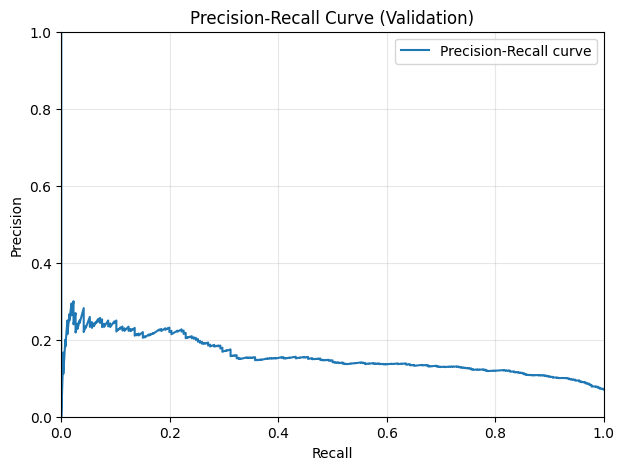

In [4]:
val_df = load_split("val")

threshold_table = plot_precision_recall_curve(
    model,
    val_df,
    feature_columns,
    title="Precision-Recall Curve (Validation)",
)

In [5]:
# inspect candidate operating points to pick a threshold
threshold_table = threshold_table.sort_values(by="recall", ascending=False)
threshold_table[threshold_table["precision"] >= 0.25].head(20)


,threshold,precision,recall
3682,0.830981,0.250000,0.101504
3698,0.839580,0.250000,0.086466
3711,0.849582,0.253165,0.075188
3710,0.849461,0.250000,0.075188
3714,0.854899,0.250000,0.071429
3715,0.854968,0.253333,0.071429
3716,0.855634,0.256757,0.071429
3718,0.856052,0.250000,0.067669
3719,0.856638,0.253521,0.067669
3736,0.865001,0.259259,0.052632


### Chosen threshold
Set `SELECTED_THRESHOLD` below based on the curve and table above.

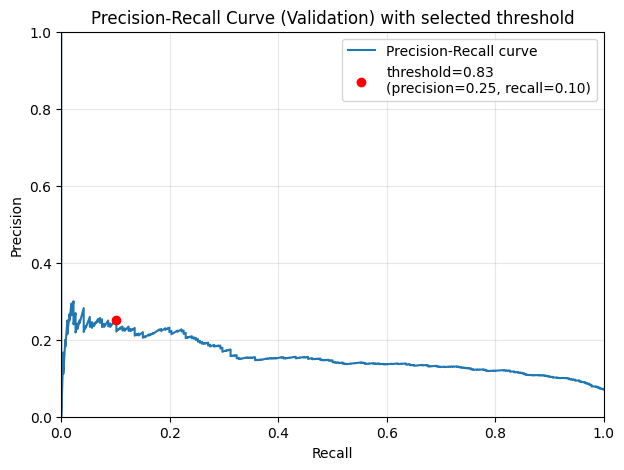

In [6]:
SELECTED_THRESHOLD = 0.830981

plot_precision_recall_curve(
    model,
    val_df,
    feature_columns,
    threshold=SELECTED_THRESHOLD,
    title="Precision-Recall Curve (Validation) with selected threshold",
);

## Final evaluation

In [7]:
evaluate_all_splits(model, feature_columns, threshold=SELECTED_THRESHOLD)

,pr_auc,precision,recall,f1,precision_at_k (k=90),recall_at_k (k=90)
train,0.129378,0.166667,0.027861,0.047742,0.177778,0.012048
val,0.158654,0.242991,0.097744,0.139410,0.233333,0.078947
test,0.134846,0.200935,0.115591,0.146758,0.188889,0.045699


## Save the model
Persist the fitted model together with its feature list and chosen threshold, so it can be reloaded for comparison and inference.

In [8]:
save_model(model, feature_columns, threshold=SELECTED_THRESHOLD)

Saved model to C:\Users\SVisbee\Repos\Credit_prediction_case\models\artifacts\log_reg_t1.joblib


WindowsPath('models/artifacts/log_reg_t1.joblib')